# 1D Shallow Water Equations (Saint-Venant System)
## Dam Break Simulation using the Rusanov (Local Lax-Friedrichs) Finite Volume Scheme

This notebook simulates a classic 1D wet-bed dam break. 
The Saint-Venant system is written as:
$$ U_t + F(U)_x = 0 $$
where $U = \begin{pmatrix} h \\ hu \end{pmatrix} = \begin{pmatrix} h \\ q \end{pmatrix}$ and $F(U) = \begin{pmatrix} q \\ \frac{q^2}{h} + \frac{gh^2}{2} \end{pmatrix}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

# --- Physical Parameters ---
g = 9.81         # Acceleration due to gravity (m/s^2)
L = 20.0         # Domain length (m)
x_dam = 0.0      # Dam position (m)

# --- Numerical Parameters ---
N = 200          # Number of interior grid cells
CFL = 0.45       # CFL safety factor (must be < 0.5 for Rusanov)
t_max = 2.0      # Total simulation time (s)

# --- Grid Setup ---
dx = L / N
# We include 1 ghost cell at each boundary, total grid size is N + 2
x = np.linspace(-L/2 - dx/2, L/2 + dx/2, N+2)

In [5]:
# --- Initial Conditions ---
# We set a high water level on the left (2m) and a lower level on the right (1m)
h = np.where(x < x_dam, 2.0, 1.0)
u = np.zeros_like(x)  # Water is initially stationary
q = h * u             # Discharge q = h * u

# Save initial state for plotting
h_init = h.copy()

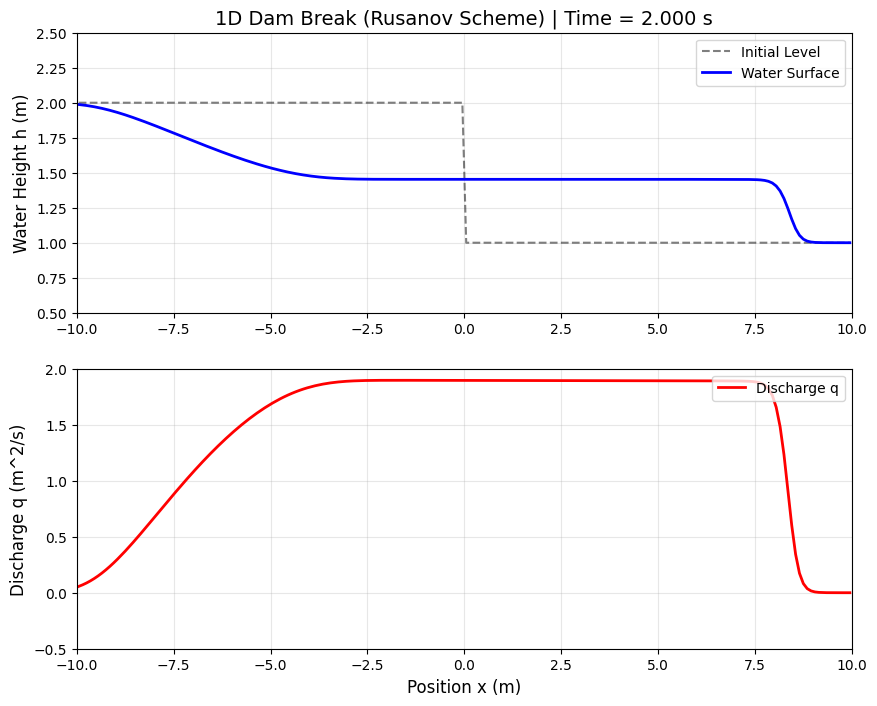

In [6]:
# Setup the plot figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

t = 0.0
step = 0

while t < t_max:
    # 1. Apply Transmissive (Neumann) Boundary Conditions
    h[0]  = h[1]
    q[0]  = q[1]
    h[-1] = h[-2]
    q[-1] = q[-2]
    
    # 2. Compute physical velocities (safely avoiding division by zero)
    u = np.where(h > 1e-5, q / h, 0.0)
    
    # 3. Dynamic Time Step calculation using local wave speeds (CFL condition)
    wave_speeds = np.abs(u) + np.sqrt(g * h)
    dt = CFL * dx / np.max(wave_speeds)
    if t + dt > t_max:
        dt = t_max - t
        
    t += dt
    step += 1
    
    # 4. Define Left and Right states at the cell interfaces
    # Interface j is located between cell j and cell j+1.
    h_L = h[:-1]
    h_R = h[1:]
    q_L = q[:-1]
    q_R = q[1:]
    u_L = u[:-1]
    u_R = u[1:]
    
    # 5. Compute Physical Fluxes at L and R states
    f_h_L = q_L
    f_q_L = (q_L**2 / h_L) + 0.5 * g * h_L**2
    
    f_h_R = q_R
    f_q_R = (q_R**2 / h_R) + 0.5 * g * h_R**2
    
    # 6. Compute maximum wave speed at each interface (Rusanov parameter)
    a_L = np.abs(u_L) + np.sqrt(g * h_L)
    a_R = np.abs(u_R) + np.sqrt(g * h_R)
    a = np.maximum(a_L, a_R)
    
    # 7. Compute Rusanov Numerical Fluxes at interfaces (size N+1)
    F_h = 0.5 * (f_h_L + f_h_R) - 0.5 * a * (h_R - h_L)
    F_q = 0.5 * (f_q_L + f_q_R) - 0.5 * a * (q_R - q_L)
    
    # 8. Update interior cell averages (indices 1 to N, i.e., 1:-1)
    h[1:-1] = h[1:-1] - (dt / dx) * (F_h[1:] - F_h[:-1])
    q[1:-1] = q[1:-1] - (dt / dx) * (F_q[1:] - F_q[:-1])
    
    # 9. Real-time Plotting (every 5 steps to save rendering time)
    if step % 5 == 0 or t >= t_max:
        ax1.clear()
        ax2.clear()
        
        # Plot Water Height
        ax1.plot(x[1:-1], h_init[1:-1], 'k--', alpha=0.5, label='Initial Level')
        ax1.plot(x[1:-1], h[1:-1], 'b-', linewidth=2, label='Water Surface')
        ax1.set_xlim(-L/2, L/2)
        ax1.set_ylim(0.5, 2.5)
        ax1.set_ylabel('Water Height h (m)', fontsize=12)
        ax1.legend(loc='upper right')
        ax1.set_title(f'1D Dam Break (Rusanov Scheme) | Time = {t:.3f} s', fontsize=14)
        ax1.grid(True, alpha=0.3)
        
        # Plot Discharge
        ax2.plot(x[1:-1], q[1:-1], 'r-', linewidth=2, label='Discharge q')
        ax2.set_xlim(-L/2, L/2)
        ax2.set_ylim(-0.5, 2.0)
        ax2.set_xlabel('Position x (m)', fontsize=12)
        ax2.set_ylabel('Discharge q (m^2/s)', fontsize=12)
        ax2.legend(loc='upper right')
        ax2.grid(True, alpha=0.3)
        
        # Force Jupyter to refresh and animate the plot
        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)

plt.close() # Close static plot to prevent duplicate output